In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
from FinMind.data import DataLoader
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS",
    "Microsoft YaHei",
    "SimHei",
    "Noto Sans CJK TC",
]
plt.rcParams["axes.unicode_minus"] = False
api = DataLoader()
# 若有帳號可登入解除頻率限制：
# api.login(user_id='你的帳號', password='你的密碼')

In [2]:
def analyze_weekly_strategy(ticker: str, years: int = 3, target_profit: float = 5.0):
    """
    分析台股股票的「週買賣停利」策略特性。
    計算任意一天進場後，未來 5 個交易日內最高價是否能達標停利點。
    
    Parameters:
        ticker (str): 股票代號，例如 '3135'
        years (int): 回溯年數，預設為 3 年
        target_profit (float): 目標停利百分比，預設為 5.0 (%)
    """
    today = datetime.today()
    start_date = (today - relativedelta(years=years)).strftime("%Y-%m-%d")
    end_date = today.strftime("%Y-%m-%d")
    print(f'回測區間: {start_date} 至 {end_date}')

    # 取得資料 (假設 api 模組已經匯入且能正常取值)
    df = api.taiwan_stock_daily(
        stock_id=ticker,
        start_date=start_date,
        end_date=end_date
    )

    df.set_index('date', inplace=True)
    df.index = pd.to_datetime(df.index)
    df = df.rename(columns={
        'max': 'High',
        'min': 'Low',
        'open': 'Open',
        'close': 'Close',
        'Trading_Volume': 'Volume'
    })

    # 新增星期幾欄位（0=週一, 4=週五）
    df['date_weekday'] = df.index.dayofweek

    # ---------------- 核心策略邏輯 ----------------

    # 1. 計算未來 5 天（一週）內的最高價
    # 使用 rolling 計算 5 天最高價，再用 shift(-5) 將結果對齊到「今天」
    # 代表「從明天開始算 5 個交易日內的最高價」
    df['Next_5D_High'] = df['High'].rolling(window=5, min_periods=1).max().shift(-5)

    # 2. 計算若以「今日收盤價」買進，未來 5 天內的最大潛在報酬率
    df['Max_Potential_Return'] = ((df['Next_5D_High'] - df['Close']) / df['Close']) * 100

    # 3. 標記是否成功達標 (例如 5%)
    df['Hit_Target'] = np.where(df['Max_Potential_Return'] >= target_profit, 1, 0)

    # 4. 計算 5 日後的「實際收盤報酬」（若沒摸到 5%，抱滿五天出場的結果）
    df['Next_5D_Close'] = df['Close'].shift(-5)
    df['Actual_5D_Return'] = ((df['Next_5D_Close'] - df['Close']) / df['Close']) * 100

    # 排除掉最後 5 天（因為未來資料還沒發生，無法計算）
    df_valid = df.dropna(subset=['Next_5D_High', 'Next_5D_Close']).copy()

    # ---------------- 統計與輸出 ----------------
    
    print("=" * 50)
    print(f"📊 [{ticker}] 週買賣策略分析 (目標停利: {target_profit}%)")
    print("-" * 50)
    
    total_days = len(df_valid)
    hit_days = df_valid['Hit_Target'].sum()
    hit_rate = (hit_days / total_days) * 100
    
    print(f"總有效交易日數: {total_days} 天")
    print(f"5日內曾達標 {target_profit}% 的天數: {hit_days} 天")
    print(f"👉 任意一天無腦進場的達標機率: {hit_rate:.2f}%")
    print()

    # 星期幾進場的勝率比較
    print("=" * 50)
    print("📊 星期幾進場最容易達標？")
    print("-" * 50)
    pivot = df_valid.pivot_table(
        values=['Hit_Target', 'Actual_5D_Return'], 
        index=['date_weekday'], 
        aggfunc='mean'
    )
    pivot['Hit_Target'] = pivot['Hit_Target'] * 100  # 轉成百分比
    pivot.index = ['週一', '週二', '週三', '週四', '週五']
    pivot = pivot[['Hit_Target', 'Actual_5D_Return']] # 調整欄位順序
    pivot.rename(columns={
        'Hit_Target': f'達標 {target_profit}% 機率(%)', 
        'Actual_5D_Return': '抱滿5天平均報酬(%)'
    }, inplace=True)
    
    print(pivot.round(2).to_string())
    print()

    # ---------------- 視覺化 ----------------
    
    # 1. 最大潛在報酬率直方圖 (看這檔股票的爆發力)
    plt.figure(figsize=(10, 5))
    df_valid['Max_Potential_Return'].hist(bins=80, color='skyblue', edgecolor='black')
    plt.axvline(x=target_profit, color='red', linestyle='dashed', linewidth=2, label=f'{target_profit}% 停利線')
    plt.xlabel('未來 5 日內最大潛在報酬率 (%)')
    plt.ylabel('出現天數')
    plt.title(f'[{ticker}] 未來 5 日最大漲幅分布 (右側越厚越好)')
    plt.legend()
    plt.show()

    # 2. 星期幾進場的勝率長條圖
    plt.figure(figsize=(8, 4))
    bars = plt.bar(pivot.index, pivot[f'達標 {target_profit}% 機率(%)'], color='coral')
    plt.axhline(y=hit_rate, color='gray', linestyle='dashed', label='總平均機率')
    plt.ylabel('達標機率 (%)')
    plt.title(f'[{ticker}] 每週各天進場達標 {target_profit}% 之機率')
    plt.legend()
    
    # 在柱狀圖上標示數值
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom')
        
    plt.ylim(0, max(100, pivot[f'達標 {target_profit}% 機率(%)'].max() + 15))
    plt.show()

    # return df_valid

2026-05-28 09:40:08.813 | INFO     | FinMind.data.finmind_api:get_data:171 - download Dataset.TaiwanStockPrice, data_id: 2308


回測區間: 2023-05-28 至 2026-05-28
📊 [2308] 週買賣策略分析 (目標停利: 5%)
--------------------------------------------------
總有效交易日數: 722 天
5日內曾達標 5% 的天數: 280 天
👉 任意一天無腦進場的達標機率: 38.78%

📊 星期幾進場最容易達標？
--------------------------------------------------
    達標 5% 機率(%)  抱滿5天平均報酬(%)
週一        40.14         1.41
週二        42.00         1.62
週三        35.37         1.77
週四        37.41         1.37
週五        38.85         1.55



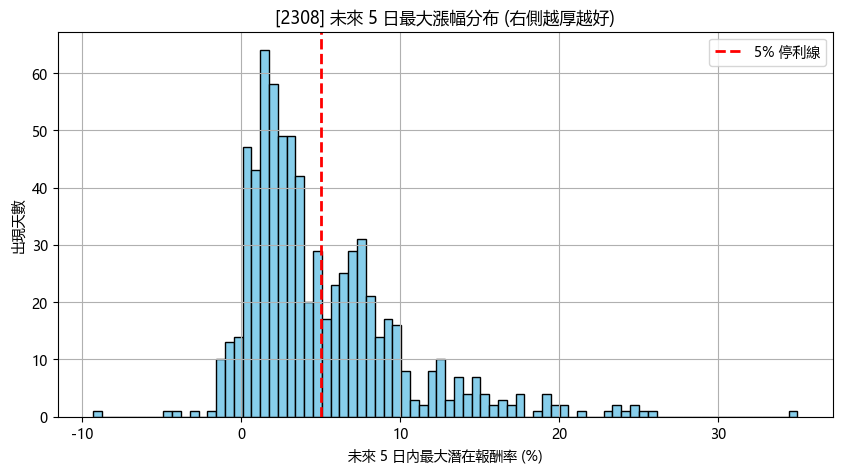

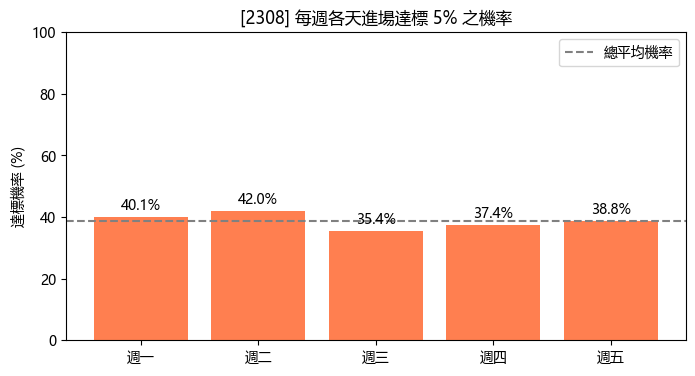

In [7]:
analyze_weekly_strategy('2308', 3, 5)